# Introducing graph structures for measles

While I am some graph structures representing Kreis-Kreis connectivity in Germany, for measles we'll need more. We'll need a way of linking each municipality to international flights data. I have a couple of thoughts for this:

**Option 1: Three-layered graph system**
The most beautiful system would probably be a graph that is a collection of L1, L2 and L3, as follows:

- *L1*: country -> airport
- *L2*: airport -> Kreis
- *L3*: Kreis   -> Kreis (what I currently have for influenza)

**Option 2: Two-layered graph system**
Option 1 seems difficult though. So I think I'll start with *L12* and *L3*, in which *L12* represents a network of the airports, connected to Kreisen, in which the airports are associated with features representing the risk factors.

This option has a couple of different suboptions. On the one hand I could introduce 

## Epidemiology data

**World Harmonization**

I got 195 countries, accross 7 continents and 22 regions.

**Global measles cases**

I got 191 countries

**Global population size**

I got 194 countries

Luckily, all of the countries in each dataset are also in the world harmonization, so I'll be using that as reference. I'll be using the entire 195 countries.

These I merge into one pd.Dataframe with 

| id | timestamp | incidence |



## Airport data

I now ultimately want:

| airport | timestamp | ori_country | passengers | incidence |

In [7]:
airport_shapes = gpd.read_file(os.path.join(get_data_env(), 'processed/international/geospatial/shapefiles/iata_airports.shp'))

shapefile_nuts3 = gpd.read_file(os.path.join(get_data_env(), 'processed/germany/geospatial/shapefiles/shape_nuts3.shp'))
shapefile_nuts2 = gpd.read_file(os.path.join(get_data_env(), 'processed/germany/geospatial/shapefiles/shape_nuts2.shp'))
shapefile_nuts1 = gpd.read_file(os.path.join(get_data_env(), 'processed/germany/geospatial/shapefiles/shape_nuts1.shp'))
shapefile_nuts0 = gpd.read_file(os.path.join(get_data_env(), 'processed/germany/geospatial/shapefiles/shape_nuts0.shp'))

Text(0.5, 1.0, 'Airports Germany with data')

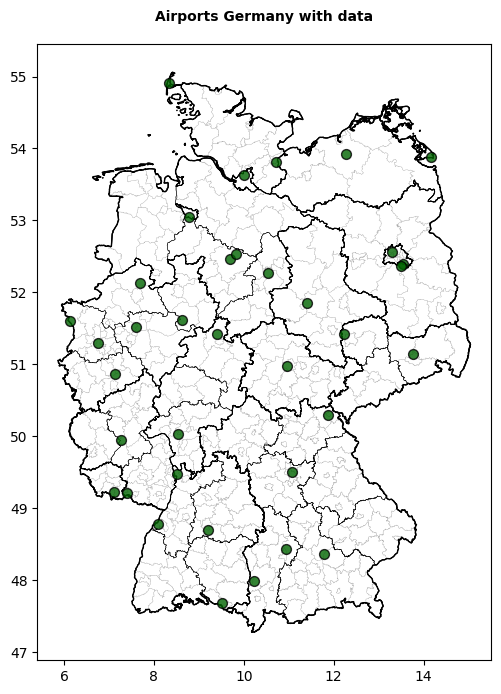

In [8]:
fig, ax = plt.subplots(1,1,figsize = (8,8))

airports_germany = airport_shapes[airport_shapes['code'].isin(list(MAIN_data['airport'].unique()))]

shapefile_nuts3.plot(ax=ax, facecolor='white', edgecolor='darkgrey', linewidth=0.2)
shapefile_nuts2.plot(ax=ax, facecolor='none',  edgecolor='black',    linewidth=0.3)
shapefile_nuts1.plot(ax=ax, facecolor='none',  edgecolor='black',    linewidth=0.7)
shapefile_nuts0.plot(ax=ax, facecolor='none',  edgecolor='black',    linewidth=1)

airports_germany.plot(ax = ax, color='darkgreen', edgecolor = 'black', alpha = 0.8, label = 'Airport', markersize = 50)
ax.set_title(f'Airports Germany with data', fontsize = 10, fontweight = 'bold', pad = 17)

## epiconfig

## AirpConfig

# geo-linking airports to Kreisen

Options
1. top - K
2. sphere of influence from airports: maximum distance within which kreisen are connected yes or no
3. distance weighted
4. gravity model: mix of distance and population

# Graph Structure Making

I now have my own version of pytorch Data and DataLoader objects. I'll need to extend those to take in multiple x, edge index and edge weight. While the y is only relevant for the nuts levels, the data and the graph data are relevant for both levels.

In [45]:
from src.utils.textformatting import align
import torch 
from dataclasses import dataclass
from typing import Optional, List

class GraphStructureError(Exception):
    def __init__(self, explanation: str):
        statement = "Error found in graphstructure!" + "\n" + explanation
        super().__init__(statement)

@dataclass
class NutsLayerGraphData:
    """
    Data for graph layer L1

    Parameters
    ----------
    x: torch.Tensor 
    edge_index: torch.Tensor 
    edge_weight: torch.Tensor 
    y: torch.Tensor
    """

    x:          torch.Tensor
    edge_index: torch.Tensor
    edge_weight:torch.Tensor
    y:          torch.Tensor
        
    def __post_init__(self):
        # validate input
        l, num_edges                        = self.edge_index.shape
        num_nodes_x, num_feat_x, num_seq_x  = self.x.shape
        num_nodes_y, num_horizon_y          = self.y.shape
        
        if l != 2:
            raise GraphStructureError('NutsLayerGraphData edge_index is expected to be of length 2')
        
        if num_edges != len(self.edge_weight):
            raise GraphStructureError(f'NutsLayerGraphData edge_index contains {num_edges} edges while edge_weight {len(self.edge_weight)} edges')     

        if num_nodes_x != num_nodes_y:
            raise GraphStructureError(f'NutsLayerGraphData x contains {num_nodes_x} nodes while y {num_nodes_y} nodes') 

        # TODO: Validate num_feat_x, num_seq_x, num_horizon_y against config                       
        
    def __repr__(self):
        cls = self.__class__.__name__
        info = (
            f"x={tuple(self.x.shape)}, "
            f"y={tuple(self.y.shape)}, "
            f"edge_index={tuple(self.edge_index.shape)}, "
            f"edge_weight={tuple(self.edge_weight.shape)}"
        )
        return f"{cls}({info})"
    
@dataclass
class AirportLayerGraphData:
    """
    Data for graph layer L2

    Parameters
    ----------
    x: torch.Tensor 
    edge_index: torch.Tensor 
    edge_weight: torch.Tensor
    """
    x:          torch.Tensor
    edge_index: torch.Tensor
    edge_weight:torch.Tensor
        
    def __repr__(self):
        cls = self.__class__.__name__
        info = (
            f"x={tuple(self.x.shape)}, "
            f"edge_index={tuple(self.edge_index.shape)}, "
            f"edge_weight={tuple(self.edge_weight.shape)}"
        )
        return f"{cls}({info})"    

    def __post_init__(self):
        # validate input
        l, num_edges                        = self.edge_index.shape
        num_nodes_x, num_feat_x, num_seq_x  = self.x.shape
        
        if l != 2:
            raise GraphStructureError('AirportLayerGraphData edge_index is expected to be of length 2')
        
        if num_edges != len(self.edge_weight):
            raise GraphStructureError(f'AirportLayerGraphData edge_index contains {num_edges} edges while edge_weight {len(self.edge_weight)} edges')     

        # TODO: Validate num_nodes_x, num_feat_x, num_seq_x, num_horizon_y against config of airport data
                
class NestedGraphData:
    """
    Data for graph layers L1 and L2 combined

    Parameters
    ----------
    nuts_layer:    NutsLayerGraphData
    airport_layer: AirportLayerGraphData
    """
    def __init__(self, 
                 nuts_layer:    NutsLayerGraphData, 
                 airport_layer: AirportLayerGraphData):
        
        # NUTS layer: L1
        self.x_l1           = nuts_layer.x 
        self.edge_index_l1  = nuts_layer.edge_index
        self.edge_weight_l1 = nuts_layer.edge_weight

        # Airport layer: L2
        self.x_l2           = airport_layer.x
        self.edge_index_l2  = airport_layer.edge_index 
        self.edge_weight_l2 = airport_layer.edge_weight 

        # Targets -> for L1
        self.y              = nuts_layer.y

        # based on airport graph
        num_airports      = self.edge_index_l2[0].max().item() + 1
        num_nodes_l2      = self.edge_index_l2[1].max().item() + 1       
        num_nodes_l1      = max(self.edge_index_l1[0].max().item(),self.edge_index_l1[1].max().item()) + 1

        if num_nodes_l1 != num_nodes_l2:
            raise GraphStructureError(f'num nodes found in L2: {num_nodes_l2} and in L1: {num_nodes_l1}')


    def to(self, device):
        """Move all tensors to device"""
        device = torch.device(device)   # Normalize device string/object
  
        self.x_l1           = self.x_l1.to(device)
        self.edge_index_l1  = self.edge_index_l1.to(device)
        self.edge_weight_l1 =self.edge_weight_l1.to(device)

        self.x_l2           = self.x_l2.to(device)  
        self.edge_index_l2  = self.edge_index_l2.to(device)
        self.edge_weight_l2 = self.edge_weight_l2.to(device)        

        self.y              = self.y.to(device)
        return self

    def cpu(self):
        """Convenience method to move to CPU"""
        return self.to('cpu')

    def cuda(self, device=None):
        """Convenience method to move to CUDA"""
        if device is None:
            return self.to('cuda')
        return self.to(f'cuda:{device}')

    @property
    def device(self):
        """Get current device of the data (from first layer's x tensor)"""
        return self.x_l1.device

    def __repr__(self):
        lines = f'<{self.__class__.__name__}(L1, L2)>'
        return lines

    def __str__(self):
        indent = 4
        keys   = ['edge_weight', 'edge_index']
        width  = max(len(k) for k in keys) + 1
        # Build output
        lines = [f'<{self.__class__.__name__}(']

        first_header = align('L1',"NUTS", 1)
        second_header = align('L2',"Airports", 1)

        lines.append(first_header)
        lines.append(" "*indent+"_"*len(first_header))
        lines.append(align('x', tuple(self.x_l1.shape), width))
        lines.append(align('edge_index', tuple(self.edge_index_l1.shape), width))        
        lines.append(align('edge_weight', tuple(self.edge_weight_l1.shape), width)) 
        lines.append('')         
        lines.append(second_header)     
        lines.append(" "*indent+"_"*len(second_header))          
        lines.append(align('x', tuple(self.x_l2.shape), width))
        lines.append(align('edge_index', tuple(self.edge_index_l2.shape), width))        
        lines.append(align('edge_weight', tuple(self.edge_weight_l2.shape), width))         
        lines.append(')>')
        
        return '\n'.join(lines)
    
class GraphDataSet:
    """
    A list of Data objects, for now limited to NestedGraphData objects

    Parameters
    ----------
    data_list: List[NestedGraphData]
    """    
    def __init__(self, data_list: List[NestedGraphData]):
        self.data_list  = data_list
        self._data_class= data_list[0].__class__.__name__

    def __iter__(self):
        return iter(self.data_list)
    
    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx: int):
        return self.data_list[idx]                   

    def __repr__(self):
        return self.__str__()

    def __str__(self) -> str:
        keys   = ['datapoints','dataclass']
        width  = max(len(k) for k in keys) + 1
        # Build output
        lines = [f'<{self.__class__.__name__}(\n']
        lines.append(align('datapoints',self.__len__(),width,newline=True))
        lines.append(align('dataclass',self._data_class, width))
        lines.append(')>')
        
        return ''.join(lines)

In [19]:
airports_germany = airport_shapes[airport_shapes['code'].isin(list(MAIN_data['airport'].unique()))]
airports_germany = tokenize_df(airports_germany, airport_token, 'code')
airports_germany = airports_germany[['code','id','geometry']]

airports_germany = gpd.GeoDataFrame(airports_germany)

nuts_nodes      = data_orchestrator.data_context.shapedata[['node','geometry']].rename(columns = {'node':'id'})

In [46]:
import geopandas as gpd
from shapely.geometry.point import Point
from shapely.geometry.polygon import Polygon
import numpy as np


class ShapefileError(Exception):
    def __init__(self, explanation: str):
        statement = "GraphBuilderL2 couldnt be initialized" + "\n" + explanation
        super().__init__(statement)

class GraphBuilderL2:

    def __init__(self, nuts_shapefile: gpd.GeoDataFrame, airport_shapefile: gpd.GeoDataFrame):
        self.nuts_shapefile     = nuts_shapefile
        self.airport_shapefile  = airport_shapefile
        
        self.expected_input_crs = 'epsg:4326' 
        self.germany_crs        = 25832

        # epsg 4326 is in degrees. Need to convert it do distance based
        self.projected_nuts_shapefile    = self.nuts_shapefile.to_crs(self.germany_crs)
        self.projected_airport_shapefile = self.airport_shapefile.to_crs(self.germany_crs)        
        
        self._validate_shapefiles()

    def _validate_shapefiles(self):      

        df_names = ['nuts shapefile', 'airport shapefile']
        for i, df in enumerate([self.nuts_shapefile, self.airport_shapefile]):

            if 'geometry' not in df.columns.tolist():
                raise ShapefileError(f'{df_names[i]} has no "geometry" column. Check column names.')
            if 'id' not in df.columns.tolist():
                raise ShapefileError(f'{df_names[i]} has no "id" column. Has this df been tokenized?')     
            if df.crs != self.expected_input_crs:
                raise ShapefileError(f'{df_names[i]} has unexpected crs ({df.crs}). Please adjust')                   

    def boolean_distance_graph(self, radius_km: float = 100.0):
    
        # Output:
        # df with columns
        # _________________________________
        # | airport_id | nuts_id | weight |
        # _________________________________

        # Build connections
        connections_ls = []
        
        for _, airport_row in self.projected_airport_shapefile.iterrows():
            
            airport_id           = airport_row['id']
            airport_geom: Point  = airport_row['geometry']
            
            for _, nuts_row in self.projected_nuts_shapefile.iterrows():

                nuts_id           = nuts_row['id']
                nuts_geom: Polygon= nuts_row['geometry']               

                # Calculate distance in meters
                # symmetry: airport_geom.distance(nuts_geom) = nuts_geom.distance(airport_geom)
                distance_km = airport_geom.distance(nuts_geom) / 1_000
                
                if distance_km <= radius_km:
                    connections_ls.append({
                        'airport_id'    : airport_id,
                        'nuts_id'       : nuts_id,
                        'weight'        : 1
                    })

        connection_df = pd.DataFrame(connections_ls)
        return self._reframe_connectiondf(connection_df)
    
    def _reframe_connectiondf(self, connection_df: pd.DataFrame) -> Tuple[torch.Tensor, torch.Tensor]:
        # Create edge_index [2, num_edges]
        edge_index  = np.stack(arrays =[connection_df['airport_id'], connection_df['nuts_id']], axis=0) 
        edge_weights= connection_df['weight']      
        return torch.tensor(edge_index),  torch.tensor(edge_weights)
        


In [42]:
gb                      = GraphBuilderL2(nuts_shapefile= nuts_nodes, airport_shapefile=airports_germany)
boolean_distance_graph  = gb.boolean_distance_graph()

In [47]:
x_l1            = gl.dataloader_collection.train[0].x
edge_index_l1   = gl.dataloader_collection.train[0].edge_index
edge_weight_l1  = gl.dataloader_collection.train[0].edge_weight
y_l1            = gl.dataloader_collection.train[0].y


edge_index_l2   = torch.tensor(boolean_distance_graph[0])
edge_weight_l2  = torch.tensor(boolean_distance_graph[1])
x_l2            = torch.rand((10, 10, 10))

/local/job_23742399/ipykernel_2005531/33729949.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index_l2   = torch.tensor(boolean_distance_graph[0])
/local/job_23742399/ipykernel_2005531/33729949.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_weight_l2  = torch.tensor(boolean_distance_graph[1])


In [48]:
data_object_nuts    = NutsLayerGraphData(x_l1, edge_index_l1, edge_weight_l1, y_l1)
data_object_airp    = AirportLayerGraphData(x_l2, edge_index_l2, edge_weight_l2)
data_object_nested  = NestedGraphData(data_object_nuts, data_object_airp)
data_list           = GraphDataSet([data_object_nested,data_object_nested,data_object_nested])

In [ ]:

@dataclass
class GraphDataLoaderCollection:
    """ 
    Stores all DataLoaders for GNN - dataloaders in attributes train/val/test/main

    Parameters
    ----------
    train: 'GraphDataLoader

    val: 'GraphDataLoader

    test: 'GraphDataLoader

    main: 'GraphDataLoader

    Downstream
    --------
    GraphDataLoaderManager: class that manages and stores GraphDataLoaderCollection
    """
    train:              'GraphDataLoader'
    val:                'GraphDataLoader'   
    test:               'GraphDataLoader'
    main:               'GraphDataLoader'

    def __repr__(self):
        return (f"<GraphDataLoaderCollection(train, val, test, main)>") 

class GraphDataLoaderManager:
    """
    DataLoader manager for GNNs. 
    An updated version of the DeepLoader class in the previous version.
    Uses the previously constructed dataorchestrator.

    Parameters
    ----------
    dataorchestrator: DataOrchestrator
        built dataorchestrator - object

    Examples
    --------
    >>> dataorchestrator= (DataOrchestrator(config).build())
    >>> graphdataloader = (GraphDataLoaderManager(dataorchestrator)
                            .retrieve_graph('identity_graph')
                            .construct_dataloaders()
                            )
    """
    def __init__(self, 
                 dataorchestrator: DataOrchestrator):
        
        self.dataorchestrator       = dataorchestrator
        self.column_registration    = dataorchestrator.column_registration
        self._graphmode: Optional[Literal['static','dynamic']] = None

    def retrieve_dynamic_graph(self, graphname:str , timesteps: Optional[List[str]] = None, frequency: str = 'yearly', graphdirectory:str = 'data/graphs'):
        """
        retrieves graphs in the folder and sets them as an instance of DynamicGraphStructure into self.graphs
        
        #TODO when timesteps = None => loop over files and import them all extracting timestep from filename
        """
        
        if isinstance(timesteps, range):
            timesteps = list(timesteps)
            timesteps = [str(t) for t in timesteps]

        graphpath  = os.path.join(graphdirectory, self.dataorchestrator.config.nuts_level, graphname)

        if frequency.lower() != 'yearly':
            raise ValueError(f'frequency of {frequency} is unsupported. Currently only yearly frequency is valid.')
        
        graphs = []
        for year in tqdm(timesteps, total = len(timesteps), desc = 'loading graphs'):

            name_t = f'{year}'

            try:
                i       = torch.load(graphpath + "/" + name_t + '_edge_index.pt', weights_only = False)
                w       = torch.load(graphpath + "/" + name_t  + '_edge_weight.pt', weights_only = False)
                self._validate_graphstructure(i, w, name_t)
                graph_t = GraphStructure(i, w)
                graphs.append(graph_t)

            except Exception as e:
                raise RuntimeError(f'graph by the name of {name_t} not found in {graphpath}')
            
        self.graph      = DynamicGraphStructure(timesteps, graphs)
        self._graphmode = 'dynamic'
        
        return self
            
    def retrieve_static_graph(self, graphname: str, graphdirectory: str = 'data/graphs') -> 'GraphDataLoaderManager':
        """
        load a graph object.

        Parameters
        ----------
        graphname: str
            The name of the file. Should correspond to the filename: f'{graphdirectory}/{graphname}/_edge_index.pt' and edge_weight.
        graphdirectory: str = 'data/graphs'
        """
    
        graphpath  = os.path.join(graphdirectory, self.dataorchestrator.config.nuts_level, graphname, graphname)
        
        try:
            i           = torch.load(graphpath + '_edge_index.pt', weights_only = False)
            w           = torch.load(graphpath + '_edge_weight.pt', weights_only = False)
            graph       = GraphStructure(i,w)
           
        except Exception as e:
            raise RuntimeError(f'graph by the name of {graphname} not found')
    
        self._validate_graphstructure(i, w, graphname)

        self.graph      = graph
        self._graphmode = 'static'
        
        return self

    def randomize_edge_weights(self) -> 'GraphDataLoaderManager':
        """
        randomizes edge weights to inspect whether a difference is observed in predictions.
        Only the case if edge_weights are intriniscally taken into account (no attention!)
        """

        w_min = self.edge_weight.min().item()
        w_max = self.edge_weight.max().item()

        randomized_weights = torch.rand_like(self.edge_weight) * (w_max - w_min) + w_min 
        self.edge_weight   = randomized_weights
        return self  

    def randomize_edges(self) -> 'GraphDataLoaderManager':
        """
        Randomly shuffles edge_index. edge_weights are unchanged.
        """
        num_nodes = int(self.edge_index.max().item()) + 1
        num_edges = self.edge_index.shape[1]

        edges_from = torch.randint(low = 0, high = num_nodes, size = (num_edges,))
        edges_to   = torch.randint(low = 0, high = num_nodes, size = (num_edges,))

        self.edge_index = torch.stack([edges_from, edges_to], dim = 0)
        return self
        
    def construct_dataloaders(self):
        """
        creates the actual dataloaders
        """
        X,y,t                             = self._construct_Xy(self.dataorchestrator.data_final.data)
        main_dataloader                   = self._construct_main_dataloader(X = X, y = y, t= t)
        self.dataloader_collection        = self._split_dataloader(main_dataloader = main_dataloader)
        return self     
    
    def _construct_Xy(self, 
                      df: pd.DataFrame) -> Tuple[torch.Tensor, torch.Tensor, List[Union[pd.Timestamp, str]]]:
        """
        constructs torch.tensor objects from df, which should be the dataorchestrator's final data object.
        
        Returns:
        -------
        X: torch.Tensor
            Input data of shape [num_timestamps, num_nodes, num_features]
        y: torch.Tensor
            Target data of shape [num_timestamps, num_nodes, horizon_size]          
        """

        dfc                 = df.copy()
        feature_arrays      = []
        target_arrays       = []
        t                   = dfc['timestamp'].unique().tolist()

        feature_cols = self.column_registration.get_by_type('feature')
        split_cols   = self.column_registration.get_by_type('split')
        target_cols  = self.column_registration.get_by_type('target')          

        time_splits         = dfc[['timestamp'] + split_cols].drop_duplicates().reset_index(drop = True)
        self.time_splits    = time_splits

        for feat in feature_cols:
            dtype = dfc[feat].dtype
            # Pivot from long to wide: rows=time, columns=nodes, values=feature
            pivoted = dfc.pivot(index=['timestamp'], columns='node', values=feat).reset_index(drop = True)

            # set missing nodes to zero
            # pivoted = pivoted.reindex(index=timestamps, columns=node_ids)

            # # convert to numeric
            pivoted = pivoted.apply(pd.to_numeric, errors='coerce')

            # # Convert to numpy float array, replace NaNs with 0
            arr = pivoted.values
            if str(dtype).startswith('int'):
                arr = arr.astype(np.int32)
            else:
                arr = arr.astype(np.float32)             # force float32 dtype

            feature_arrays.append(arr)

        X_np = np.stack(feature_arrays, axis=-1)

        for target in target_cols:
            for dfc_col in dfc.columns:
                
                if target in dfc_col and dfc_col not in feature_cols:
                    dtype = dfc[dfc_col].dtype
                    # Pivot from long to wide: rows=time, columns=nodes, values=feature
                    pivoted = dfc.pivot(index=['timestamp'], columns='node', values=dfc_col).reset_index(drop = True)

                    # set missing nodes to zero
                    # pivoted = pivoted.reindex(index=timestamps, columns=node_ids)

                    # # convert to numeric
                    pivoted = pivoted.apply(pd.to_numeric, errors='coerce')
                    
                    # # Convert to numpy float array, replace NaNs with 0
                    arr = pivoted.values
                    if str(dtype).startswith('int'):
                        arr = arr.astype(np.int32)
                    else:
                        arr = arr.astype(np.float32)   
                    target_arrays.append(arr)

        # Process target column using same approach
        y_np = np.stack(target_arrays, axis=-1)

        X = torch.tensor(X_np, dtype=torch.float)
        y = torch.tensor(y_np,dtype=torch.float)
        return X, y, t

    def _construct_main_dataloader(self, 
                                   X: torch.Tensor,
                                   y: torch.Tensor,
                                   t: List[str]) -> GraphDataLoader:
        """
        construct main dataloader based on X, y, edge_index and edge_weight

        Returns
        -------
        GraphDataLoader
        """


        dataset = []
        T       = X.shape[0]  # Total number of timesteps

        # Calculate maximum valid start position
        # Need: start + periods + prediction_horizon - 1 < T
        max_start       = T - self.dataorchestrator.config.horizon_leadtime - (self.dataorchestrator.config.horizon_size - 1) - (self.dataorchestrator.config.sequence_length - 1)
        self.max_start  = max_start

        if max_start <= 0:
            raise ValueError(f"Not enough data: T={T}, periods={self.dataorchestrator.config.sequence_length}"
                            f"Need at least {self.dataorchestrator.config.sequence_length} timesteps.")

        for t_idx, start in enumerate(range(max_start)):
            # Input window: periods consecutive timesteps
            x_seq = X[start : start + self.dataorchestrator.config.sequence_length]  # shape [periods, nodes, features]
            y_seq = y[start + self.dataorchestrator.config.sequence_length - 1]

            if self._graphmode == 'dynamic':
                year            = t[t_idx].year
                graphstructure_t = self.graph.get_snapshot(str(year))

            else:
                graphstructure_t = self.graph
            
            data = GraphData(
                x = x_seq.clone().detach().float().permute(1, 2, 0),  # (nodes, features, periods)
                y = y_seq.clone().detach().float(),                   # (nodes, horizon)
                edge_index = graphstructure_t.edge_index,
                edge_weight =graphstructure_t.edge_weight
            )
            dataset.append(data)

        return GraphDataLoader(dataset)

    def _split_dataloader(self, 
                          main_dataloader: GraphDataLoader) -> GraphDataLoaderCollection:
        """
        Splits main dataloader into those for train/val/test
        """        

        train_idx = list(self.time_splits[self.time_splits['train']].index)
        val_idx   = list(self.time_splits[self.time_splits['val']].index)
        test_idx  = list(self.time_splits[self.time_splits['test']].index)

        dataloader_train = GraphDataLoader([main_dataloader[tt] for tt in train_idx])
        dataloader_val   = GraphDataLoader([main_dataloader[tt] for tt in val_idx])
        dataloader_test  = GraphDataLoader([main_dataloader[tt] for tt in test_idx if tt < self.max_start])        
        
        return GraphDataLoaderCollection(
            train = dataloader_train,
            val   = dataloader_val,
            test  = dataloader_test,
            main  = main_dataloader
        )

    def _validate_graphstructure(self, edge_index: torch.Tensor, edge_weight: torch.Tensor, structure_name: str):
        """validates edge index and edge weight; num_nodes is compared to each other and to data_orchestrator"""
        num_nodes_graph = len(edge_index.unique())
        
        if len(edge_index[0]) != len(edge_weight):
            raise GraphStructureError(f'{error_emoji} {structure_name}: edge_index and edge_weight have a different length')
        
        if num_nodes_graph != self.dataorchestrator.data_context.num_nodes:
            raise GraphStructureError(f'{error_emoji} {structure_name}: has {num_nodes_graph} nodes while data_orchestrator has {self.dataorchestrator.data_context.num_nodes} nodes')
        
    def __repr__(self) -> str:

        representation = f'<GraphDataLoaderManager(dataloaders at .dataloader_collection)>'          
        return representation